In [71]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

In [72]:
df_a = pd.read_csv('BostonHousing - Copy.csv')
print("Initial shape:", df_a.shape)
df_a.head()

Initial shape: (506, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [73]:
n_duplicates = df_a.duplicated().sum()
print(f"Found {n_duplicates} duplicate rows.")

Found 0 duplicate rows.


In [74]:
print("\nMissing values per column:")
print(df_a.isnull().sum())


Missing values per column:
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


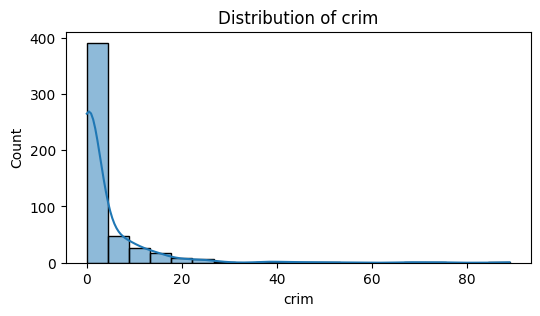

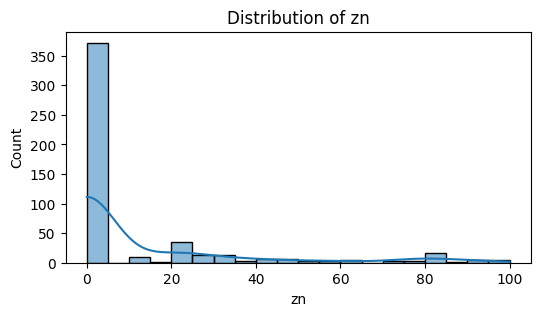

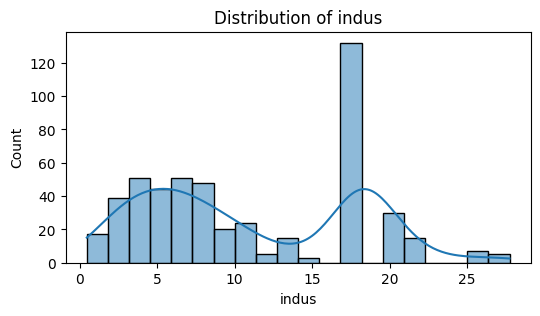

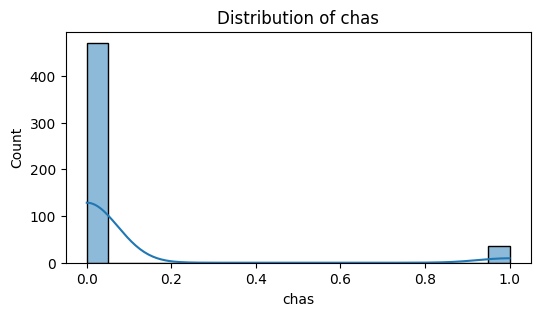

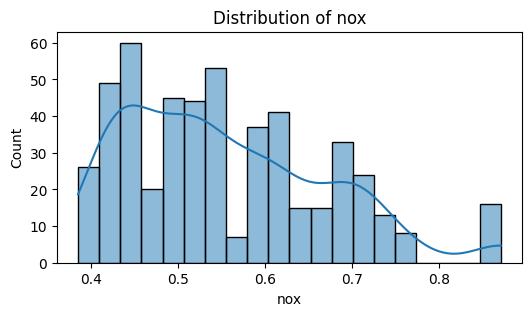

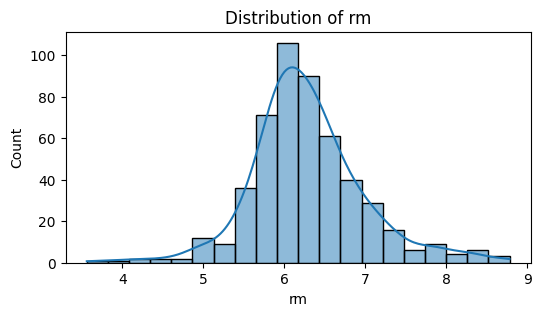

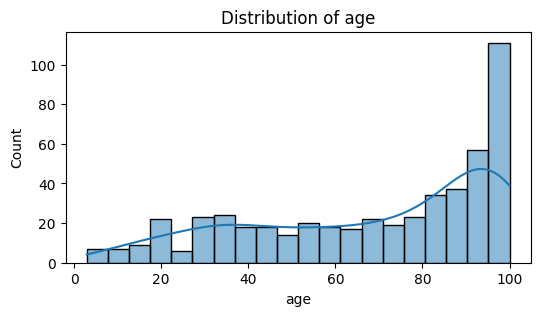

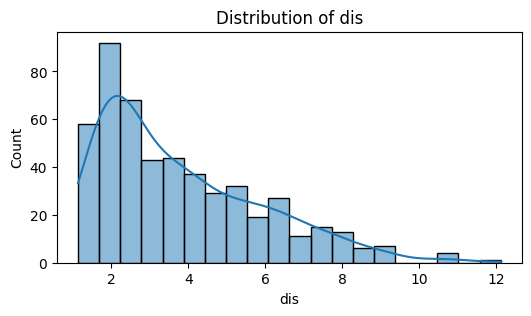

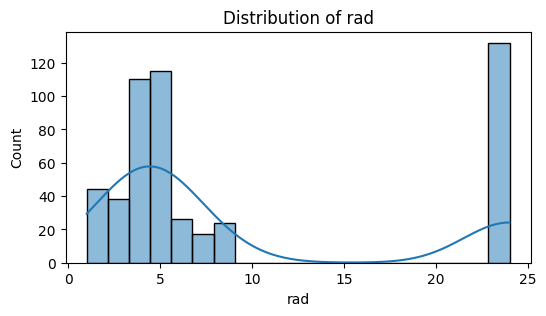

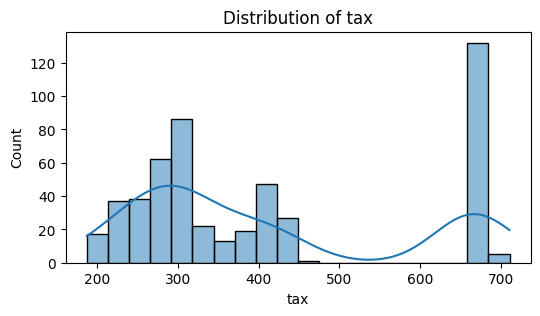

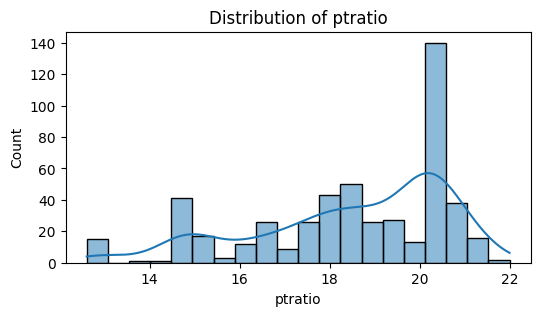

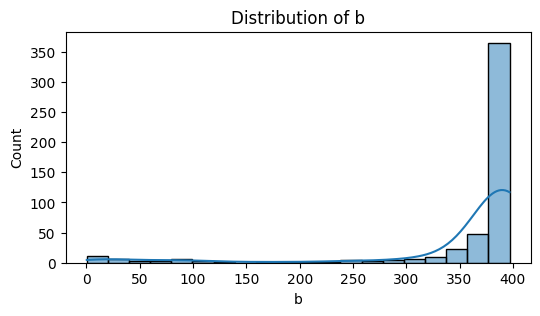

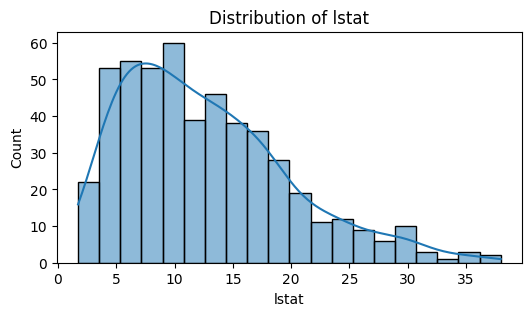

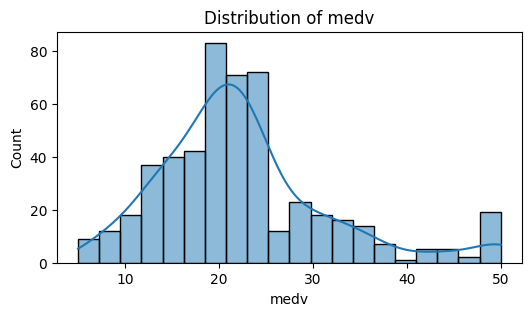

In [75]:

Columns = ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'b', 'lstat', 'medv']
for col in Columns:
    plt.figure(figsize=(6,3))
    sns.histplot(df_a[col], kde=True, bins=20)
    plt.title(f"Distribution of {col}")
    plt.show()

In [76]:

outlier_indices = dict()

for col in Columns:
    skewness = df_a[col].skew()
    print(f"\nColumn: {col:<15} skewness = {skewness:.2f}")
    
    if abs(skewness) < 0.5:
        # approximately normal → Z-score method
        zscores = np.abs(stats.zscore(df_a[col]))
        mask = zscores > 3
        method = '|Z-score| > 3'
    else:
        # skewed → IQR method
        Q1 = df_a[col].quantile(0.25)
        Q3 = df_a[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        mask = (df_a[col] < lower) | (df_a[col] > upper)
        method = 'IQR 1.5× range'
    
    idx = df_a[mask].index
    outlier_indices[col] = idx
    print(f"  Detected {len(idx)} outliers by {method}.")



Column: crim            skewness = 5.22
  Detected 66 outliers by IQR 1.5× range.

Column: zn              skewness = 2.23
  Detected 68 outliers by IQR 1.5× range.

Column: indus           skewness = 0.30
  Detected 0 outliers by |Z-score| > 3.

Column: chas            skewness = 3.41
  Detected 35 outliers by IQR 1.5× range.

Column: nox             skewness = 0.73
  Detected 0 outliers by IQR 1.5× range.

Column: rm              skewness = 0.40
  Detected 8 outliers by |Z-score| > 3.

Column: age             skewness = -0.60
  Detected 0 outliers by IQR 1.5× range.

Column: dis             skewness = 1.01
  Detected 5 outliers by IQR 1.5× range.

Column: rad             skewness = 1.00
  Detected 0 outliers by IQR 1.5× range.

Column: tax             skewness = 0.67
  Detected 0 outliers by IQR 1.5× range.

Column: ptratio         skewness = -0.80
  Detected 15 outliers by IQR 1.5× range.

Column: b               skewness = -2.89
  Detected 77 outliers by IQR 1.5× range.

Column: l

In [77]:
normal_cols = [
    col for col in Columns
    if abs(df_a[col].skew()) < 0.5
]
df_b = df_a.drop(index=np.concatenate([outlier_indices[c] 
                                           for c in normal_cols])).reset_index(drop=True)
print("\nShape after trimming normal-dist outliers:", df_b.shape)
df_b.head()


Shape after trimming normal-dist outliers: (498, 14)


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [78]:
df_c = df_b
#skewed_cols = [
#    col for col in Columns
#    if abs(df_b[col].skew()) >= 0.5
#]
#for col in skewed_cols:
#    df_c[f'Log_{col}'] = np.log1p(df_c[col])
#print("\nShape after log-transforming skewed columns:", df_c.shape)
df_c.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [79]:
df_d = df_c
#df_d.drop(columns=skewed_cols, inplace=True)
#print("\nShape after deleting original skewed columns:", df_d.shape)
#df_d.head()

In [80]:
corr_matrix = df_d.corr()
corr_matrix

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
crim,1.000000,-0.197512,0.401171,-0.054924,0.419844,-0.201623,0.348162,-0.375299,0.622499,0.578792,0.285201,-0.386695,0.447940,-0.389115
zn,-0.197512,1.000000,-0.533136,-0.040694,-0.517813,0.333150,-0.569977,0.666170,-0.308242,-0.311195,-0.391558,0.174861,-0.418353,0.368805
indus,0.401171,-0.533136,1.000000,0.057474,0.767339,-0.393594,0.648183,-0.712018,0.588996,0.716160,0.372937,-0.356387,0.608032,-0.481806
chas,-0.054924,-0.040694,0.057474,1.000000,0.085518,0.071231,0.087750,-0.098360,-0.017020,-0.045923,-0.132551,0.049472,-0.047361,0.187591
nox,0.419844,-0.517813,0.767339,0.085518,1.000000,-0.325714,0.730342,-0.767175,0.608523,0.667942,0.192518,-0.384107,0.604932,-0.447855
rm,-0.201623,0.333150,-0.393594,0.071231,-0.325714,1.000000,-0.255860,0.216788,-0.189948,-0.276657,-0.341543,0.120590,-0.631983,0.716270
age,0.348162,-0.569977,0.648183,0.087750,0.730342,-0.255860,1.000000,-0.744808,0.451720,0.505411,0.267986,-0.273984,0.612714,-0.398510
dis,-0.375299,0.666170,-0.712018,-0.098360,-0.767175,0.216788,-0.744808,1.000000,-0.488922,-0.532194,-0.238098,0.293161,-0.505815,0.267978
rad,0.622499,-0.308242,0.588996,-0.017020,0.608523,-0.189948,0.451720,-0.488922,1.000000,0.908167,0.460115,-0.446583,0.491923,-0.386076
tax,0.578792,-0.311195,0.716160,-0.045923,0.667942,-0.276657,0.505411,-0.532194,0.908167,1.000000,0.452912,-0.443338,0.547245,-0.470181


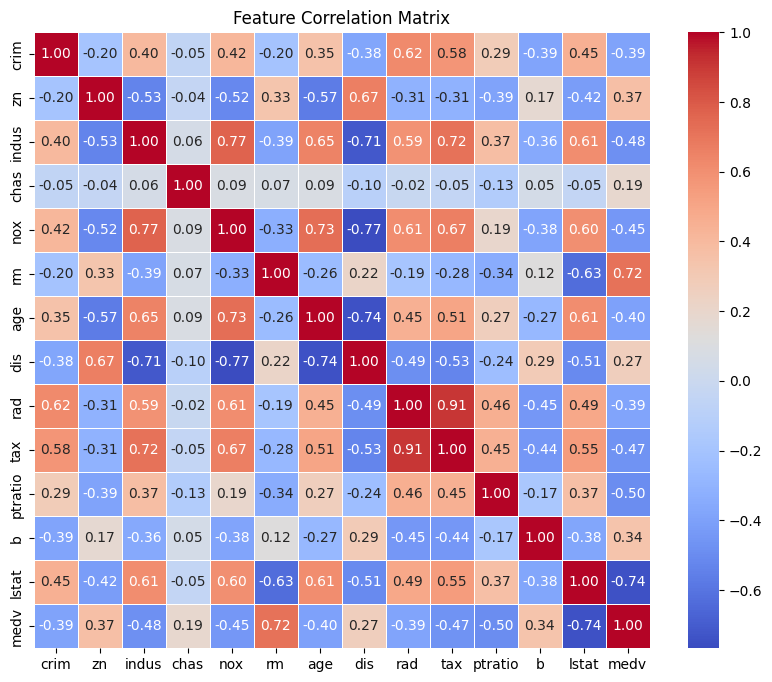

In [81]:
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True
)
plt.title("Feature Correlation Matrix")
plt.show()

In [82]:
df_e = df_d 
def low_corr_report(df: pd.DataFrame, target: str, thresh: float = 0.3):
    # 1. Compute full correlation matrix
    corr_matrix = df.corr()

    # 2. Extract correlations with the target (drop the target itself)
    corr_with_target = corr_matrix[target].drop(target)

    # 3. Filter by absolute threshold
    low_corr = corr_with_target[corr_with_target.abs() < thresh ]

    # 4. Report
    if low_corr.empty:
        print(f"No predictors have |corr| < {thresh:.2f} with '{target}'.")
    else:
        print(f"Predictors with |corr| < {thresh:.2f} to '{target}':\n")
        display(low_corr.to_frame(name=f"corr_with_{target}"))

    return low_corr.index.to_list()

low_corr = low_corr_report(df_e, target='medv', thresh=0.3)

Predictors with |corr| < 0.30 to 'medv':



,corr_with_medv
chas,0.187591
dis,0.267978


In [83]:
df_e.drop(columns=low_corr, inplace=True)

In [84]:
print("\nShape after deleting independent column to the target:", df_e.shape)
df_e.head()


Shape after deleting independent column to the target: (498, 12)


,crim,zn,indus,nox,rm,age,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0.538,6.575,65.2,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.469,6.421,78.9,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.469,7.185,61.1,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.458,6.998,45.8,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.458,7.147,54.2,3,222,18.7,396.90,5.33,36.2


In [85]:
df_f = df_e

def get_strong_predictor_correlations(df: pd.DataFrame, target: str, thresh: float = 0.7) -> pd.DataFrame:
    corr_matrix = df.corr()
    
    predictors_corr = corr_matrix.drop(index=target, columns=target)

    # Step 3: Unstack, filter, and deduplicate
    strong_pairs = (predictors_corr.abs().unstack().reset_index().rename(columns={0: 'abs_corr'}))

    strong_pairs = strong_pairs[strong_pairs['level_0'] != strong_pairs['level_1']]

    strong_pairs = strong_pairs[strong_pairs['abs_corr'] > thresh]

    # To drop duplicate pairs (e.g. A-B and B-A), sort and drop duplicates
    strong_pairs[['var1', 'var2']] = strong_pairs[['level_0', 'level_1']].apply(sorted, axis=1, result_type='expand')
    strong_pairs = strong_pairs.drop(columns=['level_0', 'level_1'])
    strong_pairs = strong_pairs.drop_duplicates()

    return strong_pairs.sort_values(by='abs_corr', ascending=False)

strong_corr_pairs = get_strong_predictor_correlations(df_f, target='medv', thresh=0.7)
print(strong_corr_pairs)

    abs_corr   var1 var2
73  0.908167    rad  tax
25  0.767339  indus  nox
38  0.730342    age  nox
29  0.716160  indus  tax


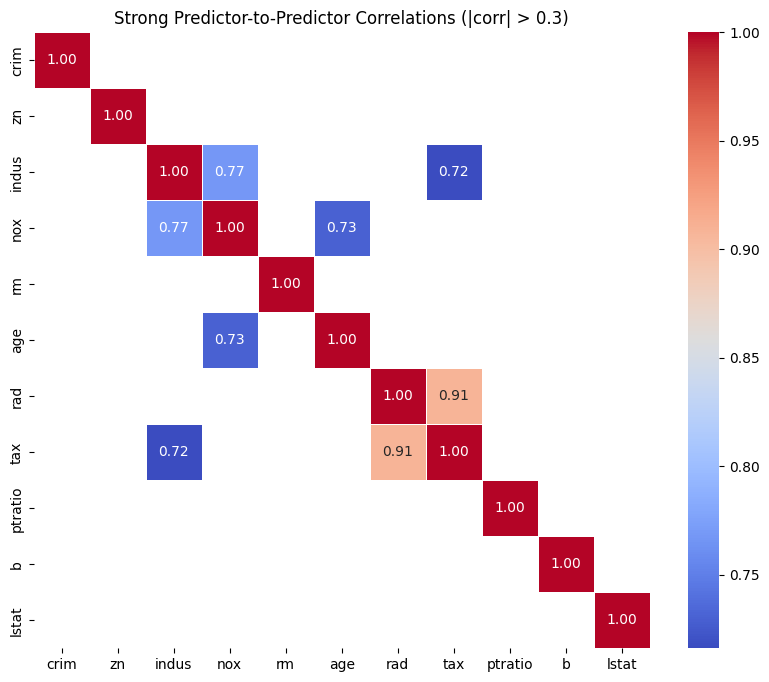

In [86]:
# Create mask of predictors only
predictor_cols = [col for col in df_f.columns if col != 'medv']
predictor_corr_matrix = df_f[predictor_cols].corr()

# Mask weaker values
mask = predictor_corr_matrix.abs() > 0.7

plt.figure(figsize=(10, 8))
sns.heatmap(
    predictor_corr_matrix.where(mask),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True
)
plt.title("Strong Predictor-to-Predictor Correlations (|corr| > 0.3)")
plt.show()

In [87]:
strong_corr_candidates = ['nox', 'rad', 'tax']
df_f.drop(columns=strong_corr_candidates, inplace=True)

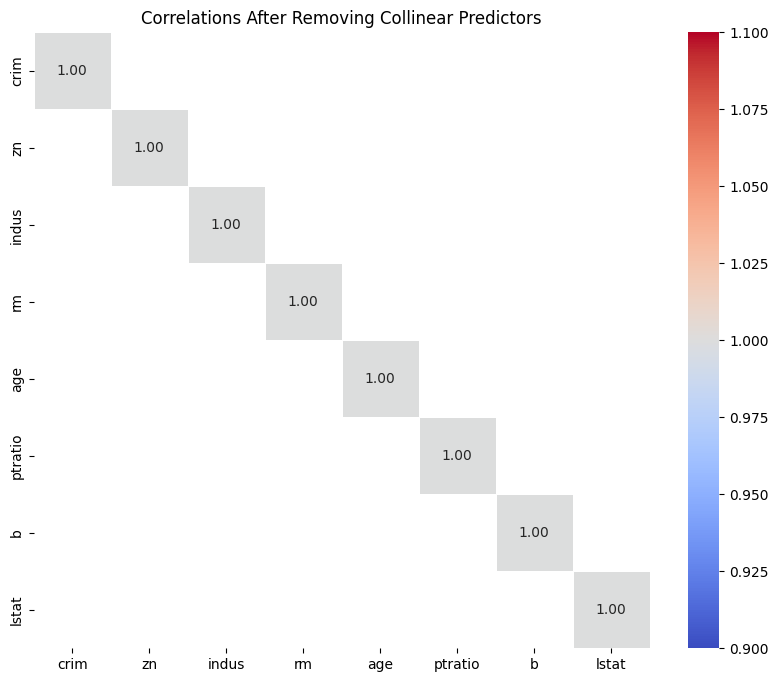

In [88]:
# Create mask of predictors only
predictor_cols = [col for col in df_f.columns if col != 'medv']
predictor_corr_matrix = df_f[predictor_cols].corr()

# Mask weaker values
mask = predictor_corr_matrix.abs() > 0.7

plt.figure(figsize=(10, 8))
sns.heatmap(
    predictor_corr_matrix.where(mask),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True
)
plt.title("Correlations After Removing Collinear Predictors")
plt.show()

In [89]:
print("\nShape after deleting independent column to the target:", df_f.shape)
df_f.head()


Shape after deleting independent column to the target: (498, 9)


,crim,zn,indus,rm,age,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,6.575,65.2,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,6.421,78.9,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,7.185,61.1,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,6.998,45.8,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,7.147,54.2,18.7,396.90,5.33,36.2


In [90]:
X = df_f.drop(columns=['medv'])
y = df_f['medv']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [91]:
df_predictions = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
df_predictions.head()

,Actual,Predicted
487,23.1,16.397337
73,23.4,24.583962
231,41.7,40.438389
175,29.4,29.276635
237,23.7,27.877289


In [92]:
def compute_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return rmse, r2

print("Model Performance:")
print(f"RMSE: {compute_metrics(y_test, y_pred)[0]:.4f}")
print(f"R2: {compute_metrics(y_test, y_pred)[1]:.44f}")

Model Performance:
RMSE: 3.7116
R2: 0.78940845393652459005551236259634606540203094


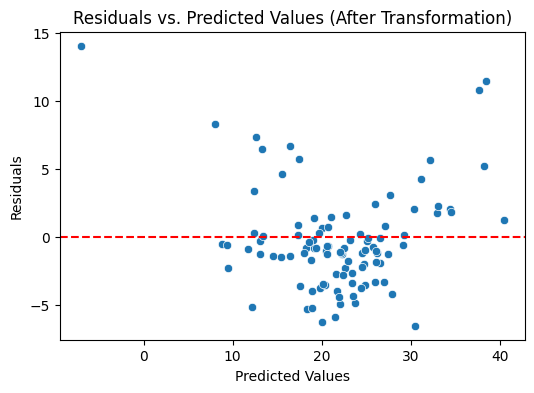

In [93]:

residuals = y_test - y_pred
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs. Predicted Values (After Transformation)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

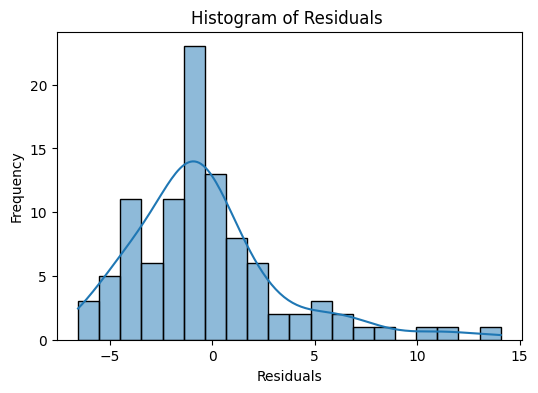

In [94]:
# Histogram of residuals
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True, bins=20)
plt.title("Histogram of Residuals ")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

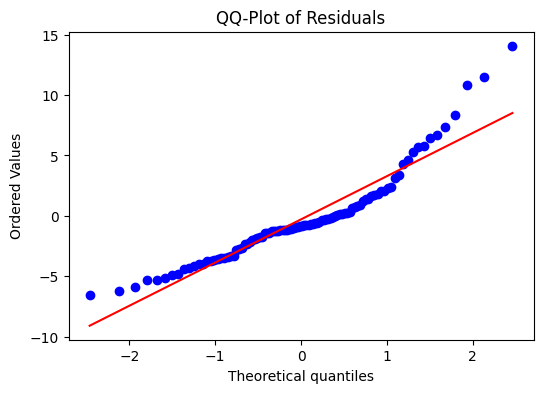

In [95]:
# 9.	Visualize normality check by an appropriate tool such as QQ-Plot and/or histogram for the overall model and also for every single predictor. It is required to implement normality check.
import scipy.stats as stats
plt.figure(figsize=(6,4))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-Plot of Residuals")
plt.show()

In [96]:
df_g = df_f.copy()

In [97]:
# 2.	Apply a Box-Cox transformation to the response variable (if all values are positive). Alternatively, apply a log transformation to the response or predictor variables*.
if (df_g['medv'] <= 0).any():
    print("Response variable 'medv' contains non-positive values; applying log1p transformation.")
    df_g['Log_medv'] = np.log1p(df_g['medv'])
    response_var = 'Log_medv'
else:
    # Apply Box-Cox transformation
    df_g['BoxCox_medv'], fitted_lambda = stats.boxcox(df_g['medv'])
    print(f"Applied Box-Cox transformation to 'medv' with lambda = {fitted_lambda:.4f}.")
    response_var = 'BoxCox_medv'

Applied Box-Cox transformation to 'medv' with lambda = 0.2415.


In [98]:
df_g

,crim,zn,indus,rm,age,ptratio,b,lstat,medv,BoxCox_medv
0,0.00632,18.0,2.31,6.575,65.2,15.3,396.90,4.98,24.0,4.779591
1,0.02731,0.0,7.07,6.421,78.9,17.8,396.90,9.14,21.6,4.555503
2,0.02729,0.0,7.07,7.185,61.1,17.8,392.83,4.03,34.7,5.610173
3,0.03237,0.0,2.18,6.998,45.8,18.7,394.63,2.94,33.4,5.520680
4,0.06905,0.0,2.18,7.147,54.2,18.7,396.90,5.33,36.2,5.710329
...,...,...,...,...,...,...,...,...,...,...
493,0.06263,0.0,11.93,6.593,69.1,21.0,391.99,9.67,22.4,4.632209
494,0.04527,0.0,11.93,6.120,76.7,21.0,396.90,9.08,20.6,4.456529
495,0.06076,0.0,11.93,6.976,91.0,21.0,396.90,5.64,23.9,4.770601
496,0.10959,0.0,11.93,6.794,89.3,21.0,393.45,6.48,22.0,4.594120


In [99]:
# 3.	Refit the regression model after applying transformations.
X = df_g.drop(columns=['medv', 'BoxCox_medv', 'Log_medv'], errors='ignore')
y = df_g[response_var]
model_box = LinearRegression()
model_box.fit(X, y)
y_pred_box = model_box.predict(X)


In [100]:
r_score = r2_score(y, y_pred_box)
print(f"R² score after transformation: {r_score:.4f}")

R² score after transformation: 0.7587


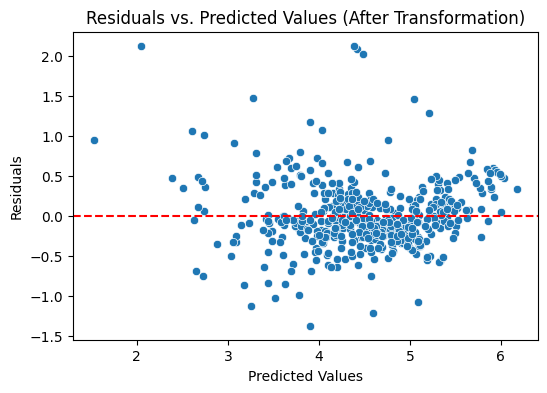

In [101]:
# 4.	Compare the residual plots, QQ plots, and model performance metrics (e.g., R2, RMSE).

residuals_box = y - y_pred_box
plt.figure(figsize=(6, 4))
sns.scatterplot(x=y_pred_box, y=residuals_box)
plt.axhline(0, color='red', linestyle='--')
plt.title("Residuals vs. Predicted Values (After Transformation)")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

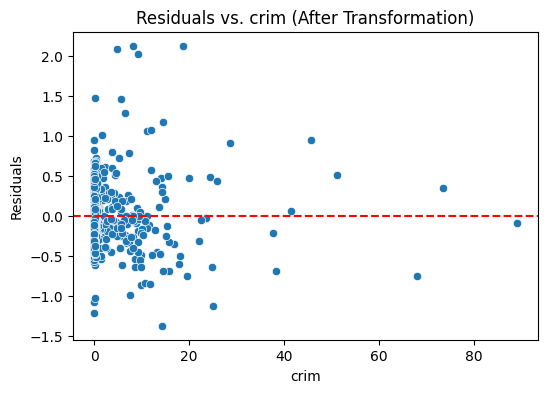

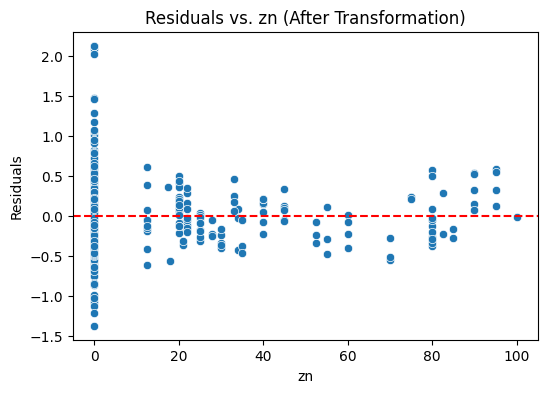

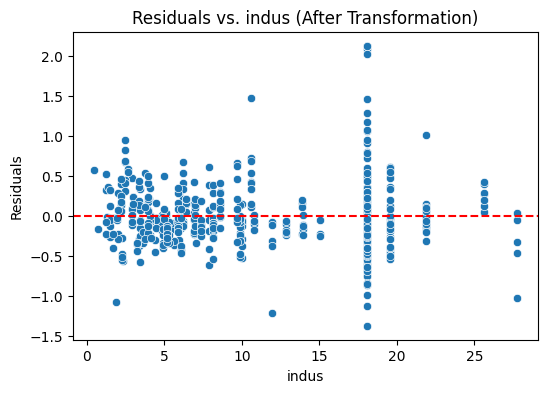

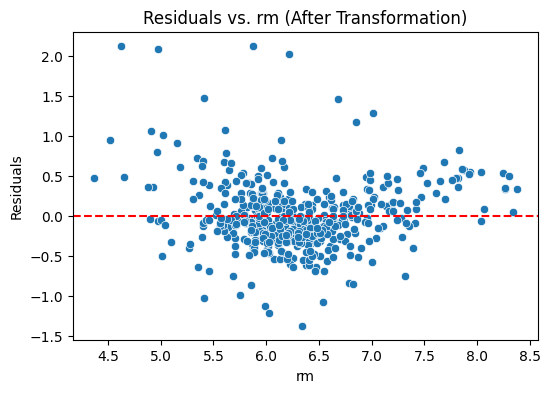

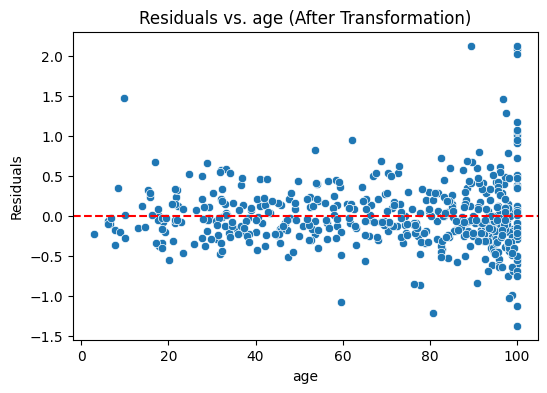

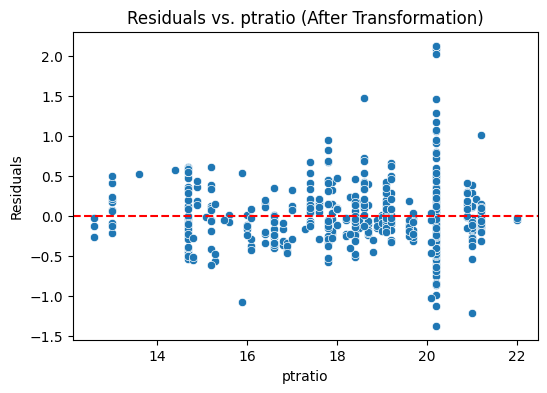

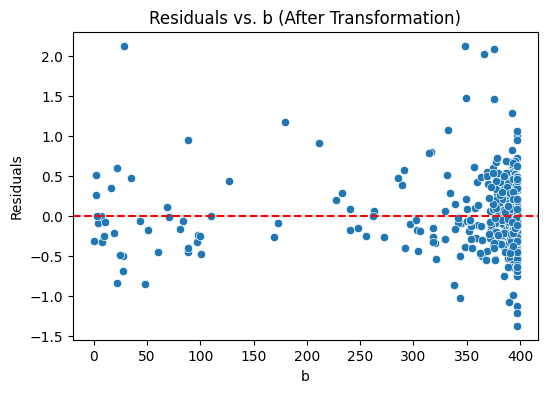

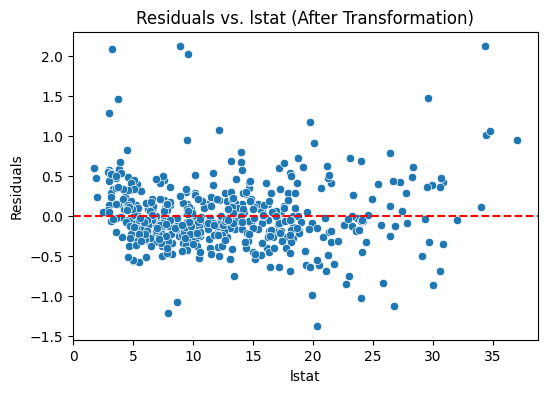

In [106]:
# Residual vs all columns
for col in X.columns:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(x=X[col], y=residuals_box)
    plt.axhline(0, color='red', linestyle='--')
    plt.title(f"Residuals vs. {col} (After Transformation)")
    plt.xlabel(col)
    plt.ylabel("Residuals")
    plt.show()

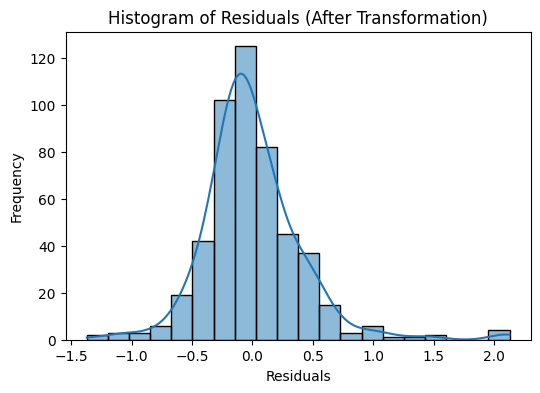

In [102]:
# Histogram of residuals
plt.figure(figsize=(6, 4))
sns.histplot(residuals_box, kde=True, bins=20)
plt.title("Histogram of Residuals (After Transformation)")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()

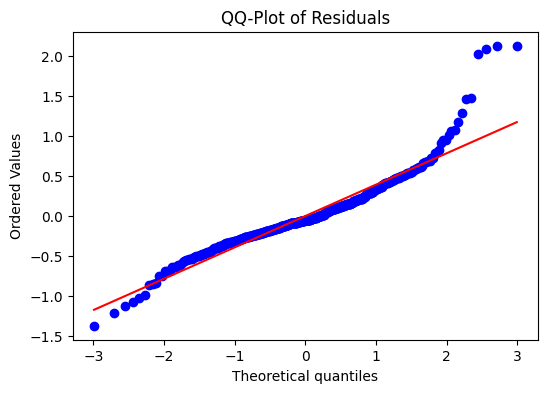

In [103]:
# 9.	Visualize normality check by an appropriate tool such as QQ-Plot and/or histogram for the overall model and also for every single predictor. It is required to implement normality check.
import scipy.stats as stats
plt.figure(figsize=(6,4))
stats.probplot(residuals_box, dist="norm", plot=plt)
plt.title("QQ-Plot of Residuals")
plt.show()

In [104]:
R2 = r_score
RMSE = np.sqrt(mean_squared_error(y, y_pred_box))
print(f"Model Performance after Transformation:\nR²: {R2:.4f}\nRMSE: {RMSE:.4f}")

Model Performance after Transformation:
R²: 0.7587
RMSE: 0.4095


In [105]:
# 5.	Apply ANOVA test to check for significance of the predictors.
anova_data = df_g.copy()
anova_data[response_var] = y
formula = f"{response_var} ~ " + " + ".join(X.columns)
model_anova = smf.ols(formula=formula, data=anova_data).fit()
anova_results = anova_lm(model_anova)
print("\nANOVA Results:")
print(anova_results)


ANOVA Results:
             df     sum_sq    mean_sq           F        PR(>F)
crim        1.0  85.290789  85.290789  499.441284  9.439779e-77
zn          1.0  27.306826  27.306826  159.901865  6.558541e-32
indus       1.0  23.062728  23.062728  135.049498  9.800357e-28
rm          1.0  79.984420  79.984420  468.368527  2.363500e-73
age         1.0   4.013828   4.013828   23.503961  1.677296e-06
ptratio     1.0  10.839832  10.839832   63.475311  1.150454e-14
b           1.0   8.274129   8.274129   48.451208  1.094435e-11
lstat       1.0  23.767337  23.767337  139.175510  1.934103e-28
Residual  489.0  83.507706   0.170772         NaN           NaN
